# HFE Property Plots

Sources:
- `analysis/docs/3M Novec 7000 Engineered Fluid TDS Heat Transfer_FINAL.pdf`
- `analysis/docs/HFE 7200 Technical Data.pdf`
- `analysis/docs/HFE Freezing Data.pdf`
- Seeton, C. J. (2006), `Viscosity-temperature correlation for liquids`, DOI: `10.1007/s11249-006-9071-2`
- 3M Thermal Management Fluids brochure for the HFE 7200 25°C thermal-property table

The viscosity points below are transcribed from the final slide of `HFE Freezing Data.pdf`. Both viscosity curves use Seeton fits to those measured points. The Seeton correlation was developed for low-viscosity halocarbons and low-temperature fluids, which is the relevant regime here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, least_squares
from scipy.special import k0
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter

FIGSIZE = (12, 9)
COLORS = {
    'HFE 7000': '#1f77b4',
    'HFE 7200': '#d62728',
}

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 22,
    'axes.labelsize': 28,
    'axes.titlesize': 28,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 21,
    'lines.linewidth': 3.2,
    'lines.markersize': 10,
    'axes.grid': False,
    'grid.alpha': 0.28,
    'grid.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'analysis' / 'docs').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing analysis/docs.')


REPO_ROOT = find_repo_root()
DOCS_DIR = REPO_ROOT / 'analysis' / 'docs'
FIGURE_DIR = REPO_ROOT / 'analysis' / 'tmp' / 'hfe_properties'
SAVE_FIGURES = False
X_AXIS_MIN_C = -125.0
X_AXIS_MAX_C = 30.0
X_AXIS_TICKS_C = [-125, -100, -75, -50, -25, 0, 25]
EQUATION_FONT_SIZE = 15


def save_figure(fig: plt.Figure, stem: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(FIGURE_DIR / f'{stem}.png', bbox_inches='tight')


def style_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=0.34, linewidth=1.0)
    ax.grid(True, which='minor', alpha=0.16, linewidth=0.6)


def style_temperature_axis(ax):
    ax.set_xlim(X_AXIS_MIN_C, X_AXIS_MAX_C)
    ax.set_xticks(X_AXIS_TICKS_C)


def style_log_y_axis(ax):
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())


def add_equation_box(ax, text, loc='lower left', fontsize=EQUATION_FONT_SIZE):
    positions = {
        'lower left': (0.03, 0.04, 'left', 'bottom'),
        'lower right': (0.97, 0.04, 'right', 'bottom'),
        'upper left': (0.03, 0.96, 'left', 'top'),
        'upper right': (0.97, 0.96, 'right', 'top'),
    }
    x_pos, y_pos, ha, va = positions[loc]
    ax.text(
        x_pos,
        y_pos,
        text,
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=fontsize,
        linespacing=1.35,
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'edgecolor': '0.8', 'alpha': 0.9},
    )


In [2]:
# Viscosity points from HFE Freezing Data.pdf, final slide.
viscosity_points = pd.DataFrame(
    {
        'temperature_c': [25.0, 0.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -100.0, -120.0],
        'HFE 7000': [0.32, 0.42, 0.47, 0.55, 0.66, 0.78, 0.95, 1.19, 1.53, 3.69, 11.87],
        'HFE 7200': [0.41, 0.67, 0.78, 0.93, 1.14, 1.42, 1.84, 2.48, 3.72, 12.47, 64.47],
    }
).sort_values('temperature_c')


SEETON_MIN_VISCOSITY_CST = 0.04
SEETON_BESSEL_OFFSET_CST = 1.244067


def seeton_viscosity_transform(viscosity_cst):
    """Seeton viscosity transform for kinematic viscosity in cSt."""
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    correction = np.exp(-viscosity_cst) * k0(viscosity_cst + SEETON_BESSEL_OFFSET_CST)
    return np.log(np.log(viscosity_cst + 0.7 + correction))


def invert_seeton_transform(target_transform, high_start_cst):
    """Invert the Seeton transform numerically because the Bessel term has no closed-form inverse."""
    target_transform = float(target_transform)
    low_cst = SEETON_MIN_VISCOSITY_CST
    low_transform = float(seeton_viscosity_transform(low_cst))
    if target_transform < low_transform:
        raise ValueError('Seeton fit evaluated below the 0.04 cSt lower validity limit.')

    high_cst = max(float(high_start_cst), 2.0 * low_cst)
    while float(seeton_viscosity_transform(high_cst)) < target_transform:
        high_cst *= 2.0
        if high_cst > 1.0e8:
            raise RuntimeError('Could not bracket the Seeton viscosity inversion.')

    return brentq(
        lambda trial_cst: float(seeton_viscosity_transform(trial_cst)) - target_transform,
        low_cst,
        high_cst,
        xtol=1.0e-10,
        rtol=1.0e-10,
    )


def evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst):
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    target_transform = coefficient_a - coefficient_b * np.log(temperature_k)
    flat_result = [
        invert_seeton_transform(target_value, high_start_cst)
        for target_value in np.ravel(target_transform)
    ]
    return np.asarray(flat_result).reshape(target_transform.shape)


def fit_seeton_viscosity(temperature_c, viscosity_cst):
    """Fit ln(ln(nu + 0.7 + exp(-nu) K0(nu + 1.244067))) = A - B ln(T_K)."""
    temperature_c = np.asarray(temperature_c, dtype=float)
    temperature_k = temperature_c + 273.15
    viscosity_cst = np.asarray(viscosity_cst, dtype=float)
    high_start_cst = max(2.0 * float(np.max(viscosity_cst)), 1.0)

    transformed_viscosity = seeton_viscosity_transform(viscosity_cst)
    slope, intercept = np.polyfit(np.log(temperature_k), transformed_viscosity, 1)
    initial_guess = np.array([float(intercept), float(-slope)])

    def fitted_viscosity(params):
        coefficient_a, coefficient_b = params
        return evaluate_seeton_viscosity(temperature_c, coefficient_a, coefficient_b, high_start_cst)

    def log_residual(params):
        return np.log(fitted_viscosity(params)) - np.log(viscosity_cst)

    result = least_squares(log_residual, initial_guess)
    coefficient_a, coefficient_b = result.x

    def evaluate(new_temperature_c):
        return evaluate_seeton_viscosity(new_temperature_c, coefficient_a, coefficient_b, high_start_cst)

    params = {
        'A': float(coefficient_a),
        'B': float(coefficient_b),
        'log_rmse': float(np.sqrt(np.mean(log_residual(result.x) ** 2))),
    }
    return params, evaluate


hfe7000_seeton_params, hfe7000_kinematic_viscosity_seeton_cst = fit_seeton_viscosity(
    viscosity_points['temperature_c'],
    viscosity_points['HFE 7000'],
)
hfe7200_seeton_params, hfe7200_kinematic_viscosity_seeton_cst = fit_seeton_viscosity(
    viscosity_points['temperature_c'],
    viscosity_points['HFE 7200'],
)

seeton_fit_summary = pd.DataFrame(
    [hfe7000_seeton_params, hfe7200_seeton_params],
    index=['HFE 7000', 'HFE 7200'],
)
display(viscosity_points)
display(seeton_fit_summary.round({'A': 3, 'B': 3, 'log_rmse': 4}))


,temperature_c,HFE 7000,HFE 7200
10,-120.0,11.87,64.47
9,-100.0,3.69,12.47
8,-70.0,1.53,3.72
7,-60.0,1.19,2.48
6,-50.0,0.95,1.84
5,-40.0,0.78,1.42
4,-30.0,0.66,1.14
3,-20.0,0.55,0.93
2,-10.0,0.47,0.78
1,0.0,0.42,0.67


,A,B,log_rmse
HFE 7000,22.344,4.256,0.0322
HFE 7200,22.383,4.161,0.1056


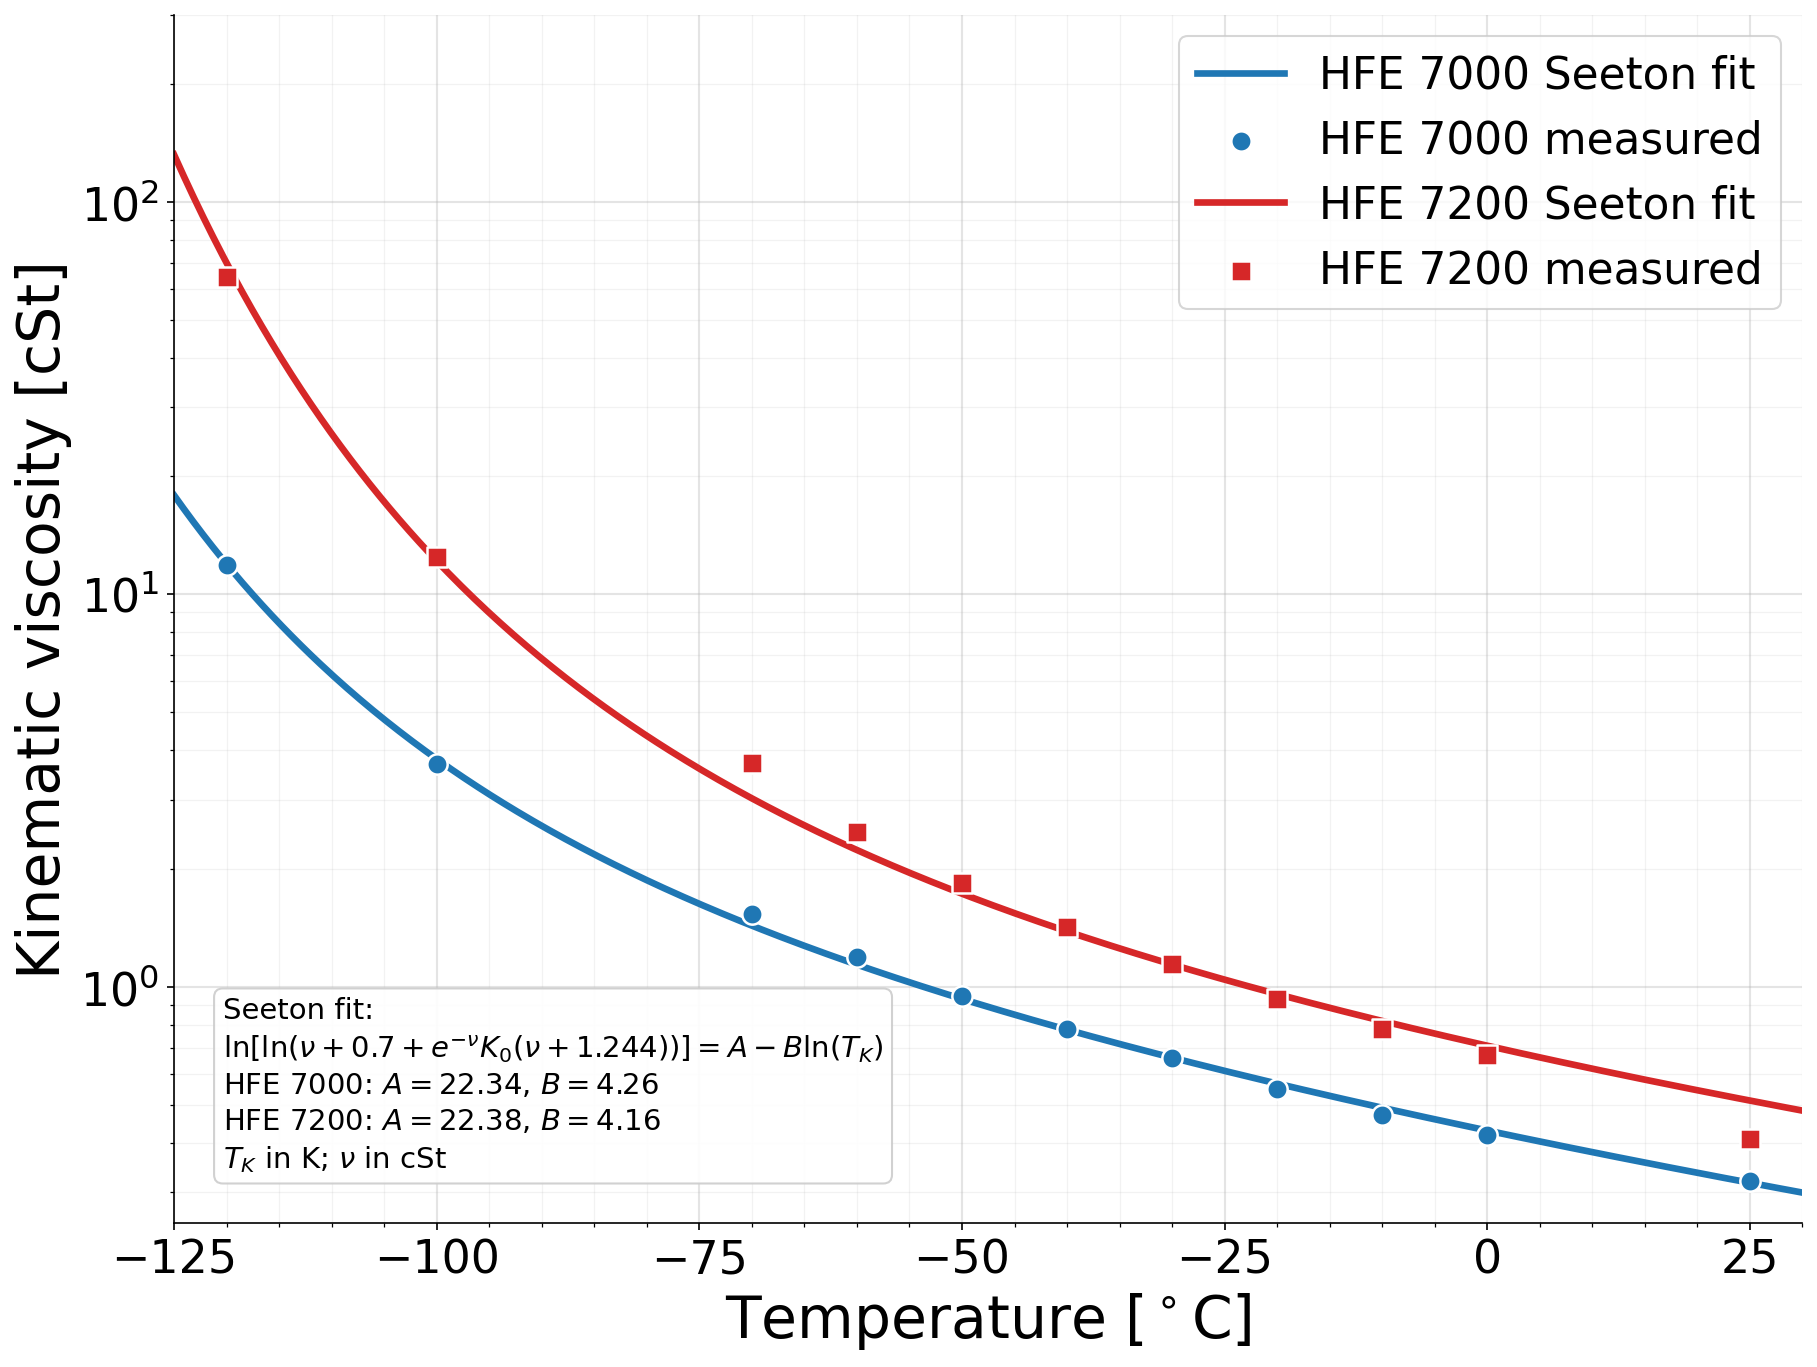

In [3]:
temperature_viscosity_c = np.linspace(X_AXIS_MIN_C, X_AXIS_MAX_C, 500)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    temperature_viscosity_c,
    hfe7000_kinematic_viscosity_seeton_cst(temperature_viscosity_c),
    color=COLORS['HFE 7000'],
    label='HFE 7000 Seeton fit',
)
ax.scatter(
    viscosity_points['temperature_c'],
    viscosity_points['HFE 7000'],
    s=95,
    color=COLORS['HFE 7000'],
    edgecolor='white',
    linewidth=1.2,
    zorder=3,
    label='HFE 7000 measured',
)

ax.plot(
    temperature_viscosity_c,
    hfe7200_kinematic_viscosity_seeton_cst(temperature_viscosity_c),
    color=COLORS['HFE 7200'],
    label='HFE 7200 Seeton fit',
)
ax.scatter(
    viscosity_points['temperature_c'],
    viscosity_points['HFE 7200'],
    s=95,
    color=COLORS['HFE 7200'],
    marker='s',
    edgecolor='white',
    linewidth=1.2,
    zorder=3,
    label='HFE 7200 measured',
)

ax.set_xlabel(r'Temperature [$^\circ$C]')
ax.set_ylabel('Kinematic viscosity [cSt]')
style_temperature_axis(ax)
ax.set_ylim(0.25, 300)
ax.set_yscale('log')
style_axes(ax)
style_log_y_axis(ax)
viscosity_equation_text = (
    'Seeton fit:'
    '\n'
    r'$\ln[\ln(\nu+0.7+e^{-\nu}K_0(\nu+1.244))] = A - B\ln(T_K)$'
    '\n'
    rf'HFE 7000: $A={hfe7000_seeton_params["A"]:.2f}$, $B={hfe7000_seeton_params["B"]:.2f}$'
    '\n'
    rf'HFE 7200: $A={hfe7200_seeton_params["A"]:.2f}$, $B={hfe7200_seeton_params["B"]:.2f}$'
    '\n'
    r'$T_K$ in K; $\nu$ in cSt'
)
add_equation_box(ax, viscosity_equation_text, loc='lower left', fontsize=14)
ax.legend(loc='upper right')

save_figure(fig, 'hfe_7000_7200_kinematic_viscosity')
plt.show()


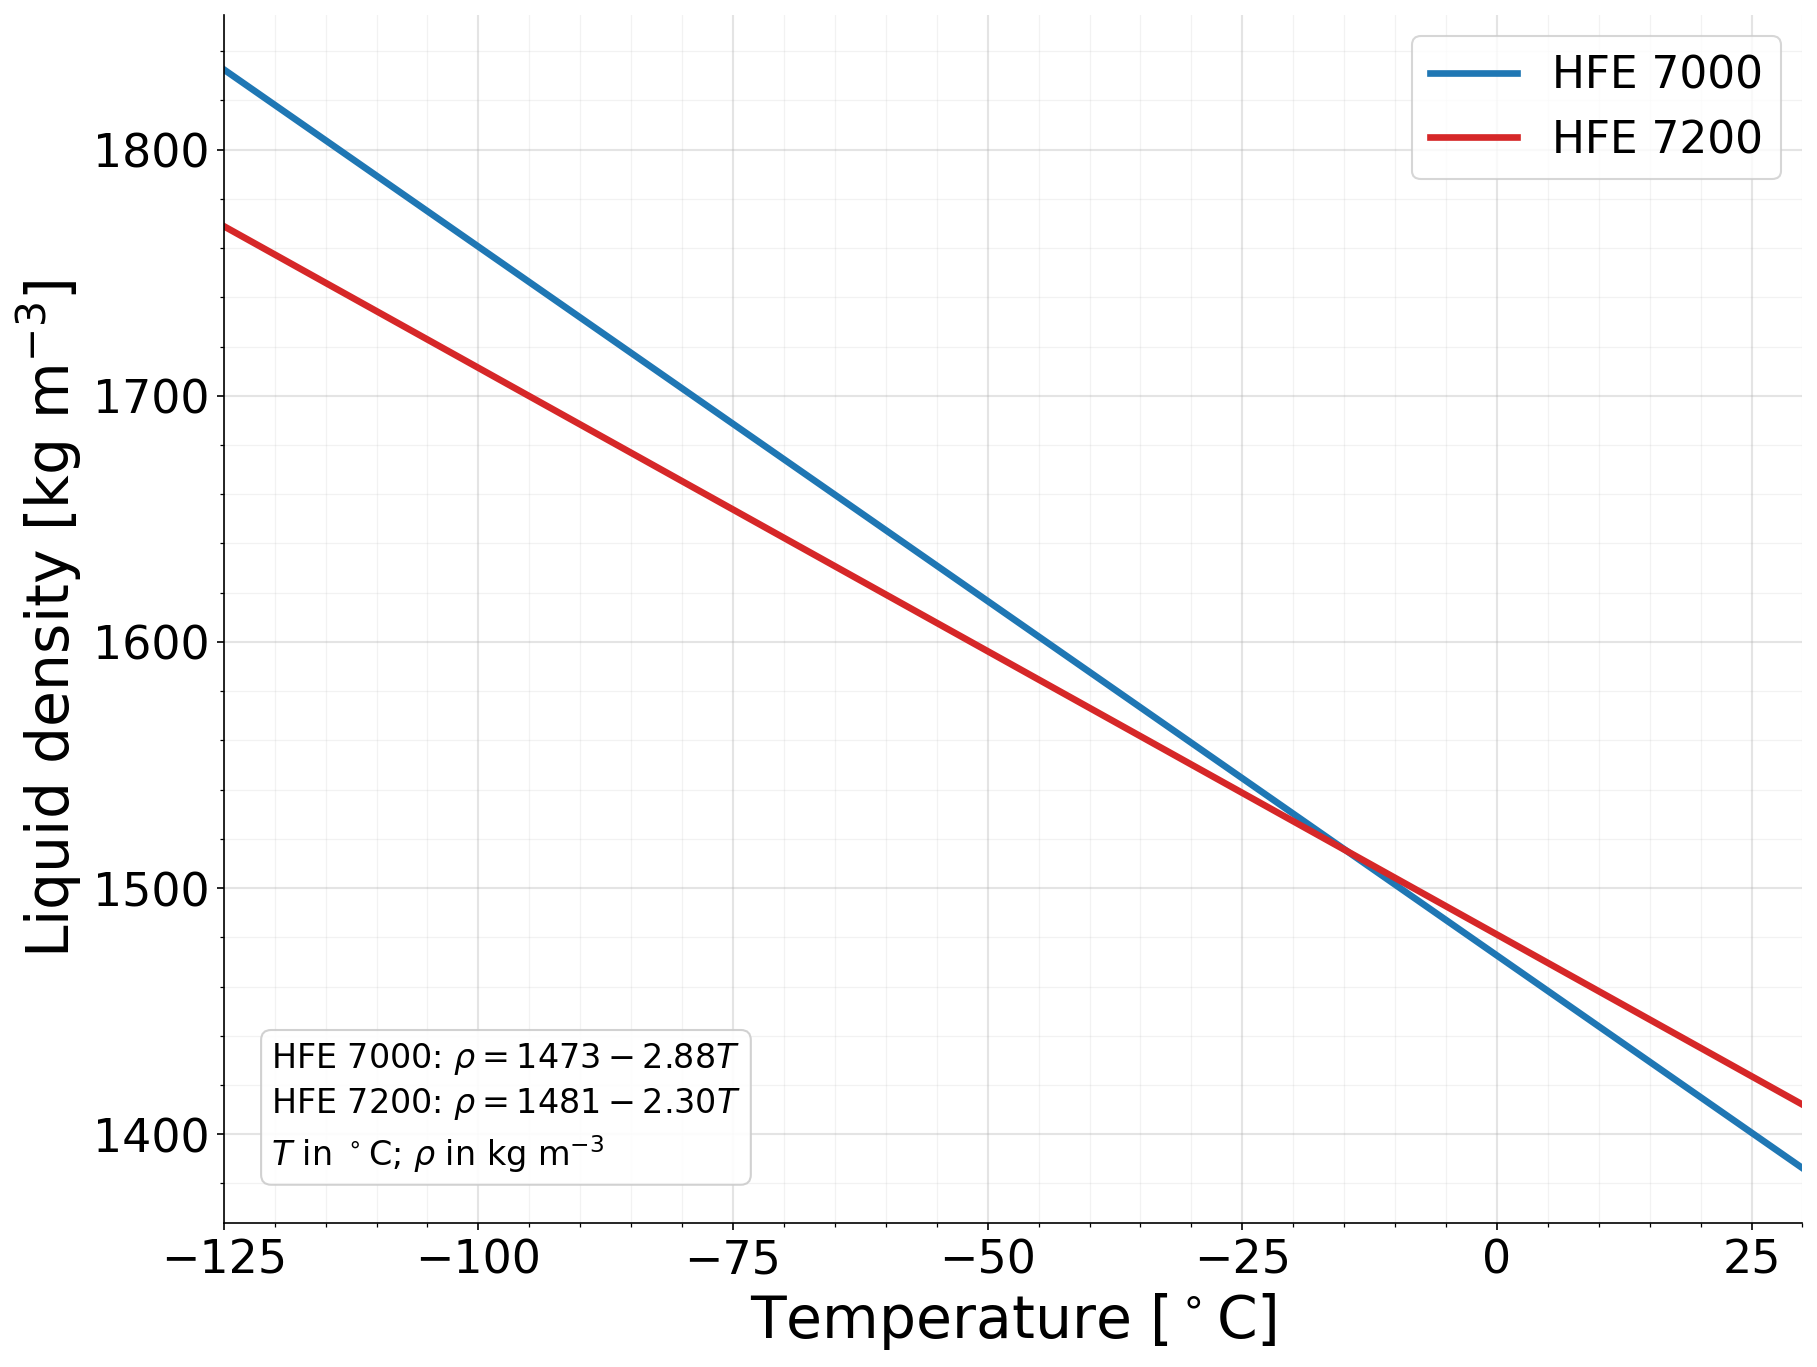

In [4]:
def hfe7000_density_kg_m3(temperature_c):
    """3M Novec 7000 TDS liquid density, kg/m^3."""
    return 1472.6 - 2.880 * np.asarray(temperature_c, dtype=float)


def hfe7200_density_kg_m3(temperature_c):
    """3M Novec 7200 TDS liquid density, converted from g/mL to kg/m^3."""
    return 1000.0 * (1.4811 - 0.0023026 * np.asarray(temperature_c, dtype=float))


temperature_density_c = np.linspace(X_AXIS_MIN_C, X_AXIS_MAX_C, 500)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    temperature_density_c,
    hfe7000_density_kg_m3(temperature_density_c),
    color=COLORS['HFE 7000'],
    label='HFE 7000',
)
ax.plot(
    temperature_density_c,
    hfe7200_density_kg_m3(temperature_density_c),
    color=COLORS['HFE 7200'],
    label='HFE 7200',
)

ax.set_xlabel(r'Temperature [$^\circ$C]')
ax.set_ylabel(r'Liquid density [kg m$^{-3}$]')
style_temperature_axis(ax)
style_axes(ax)
density_equation_text = (
    r'HFE 7000: $\rho = 1473 - 2.88T$'
    '\n'
    r'HFE 7200: $\rho = 1481 - 2.30T$'
    '\n'
    r'$T$ in $^\circ$C; $\rho$ in kg m$^{-3}$'
)
add_equation_box(ax, density_equation_text, loc='lower left', fontsize=16)
ax.legend(loc='upper right')

save_figure(fig, 'hfe_7000_7200_density')
plt.show()


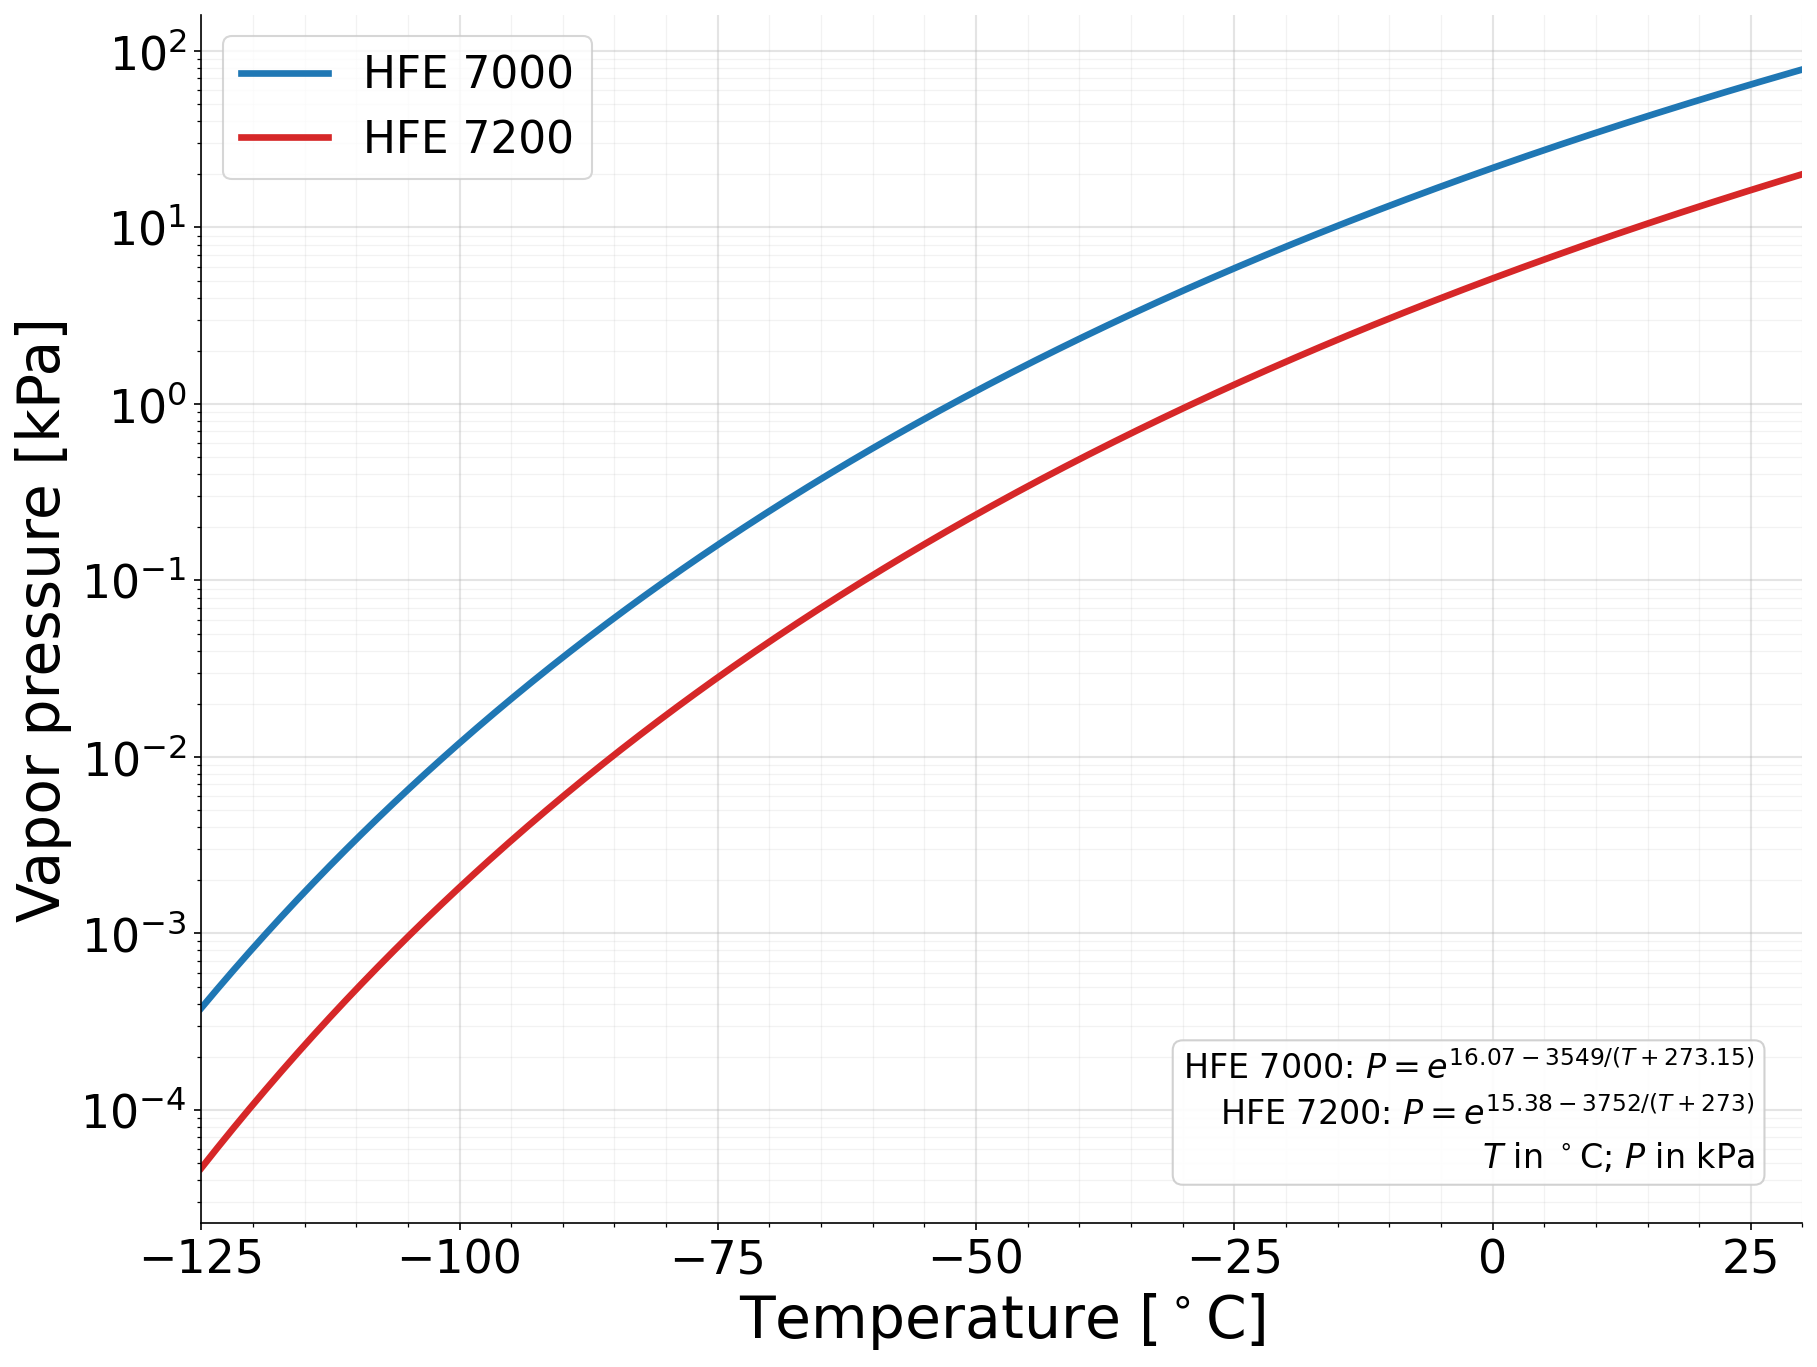

In [5]:
def hfe7000_vapor_pressure_pa(temperature_c):
    """3M Novec 7000 TDS vapor-pressure equation, Pa."""
    temperature_k = np.asarray(temperature_c, dtype=float) + 273.15
    return np.exp(-3548.6 / temperature_k + 22.978)


def hfe7200_vapor_pressure_pa(temperature_c):
    """3M Novec 7200 TDS vapor-pressure equation, Pa."""
    temperature_k = np.asarray(temperature_c, dtype=float) + 273.0
    return np.exp(22.289 - 3752.1 / temperature_k)


temperature_vapor_c = np.linspace(X_AXIS_MIN_C, X_AXIS_MAX_C, 600)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    temperature_vapor_c,
    hfe7000_vapor_pressure_pa(temperature_vapor_c) / 1000.0,
    color=COLORS['HFE 7000'],
    label='HFE 7000',
)
ax.plot(
    temperature_vapor_c,
    hfe7200_vapor_pressure_pa(temperature_vapor_c) / 1000.0,
    color=COLORS['HFE 7200'],
    label='HFE 7200',
)

ax.set_xlabel(r'Temperature [$^\circ$C]')
ax.set_ylabel('Vapor pressure [kPa]')
style_temperature_axis(ax)
ax.set_yscale('log')
style_axes(ax)
style_log_y_axis(ax)
vapor_equation_text = (
    r'HFE 7000: $P = e^{16.07 - 3549/(T+273.15)}$'
    '\n'
    r'HFE 7200: $P = e^{15.38 - 3752/(T+273)}$'
    '\n'
    r'$T$ in $^\circ$C; $P$ in kPa'
)
add_equation_box(ax, vapor_equation_text, loc='lower right', fontsize=16)
ax.legend(loc='upper left')

save_figure(fig, 'hfe_7000_7200_vapor_pressure')
plt.show()


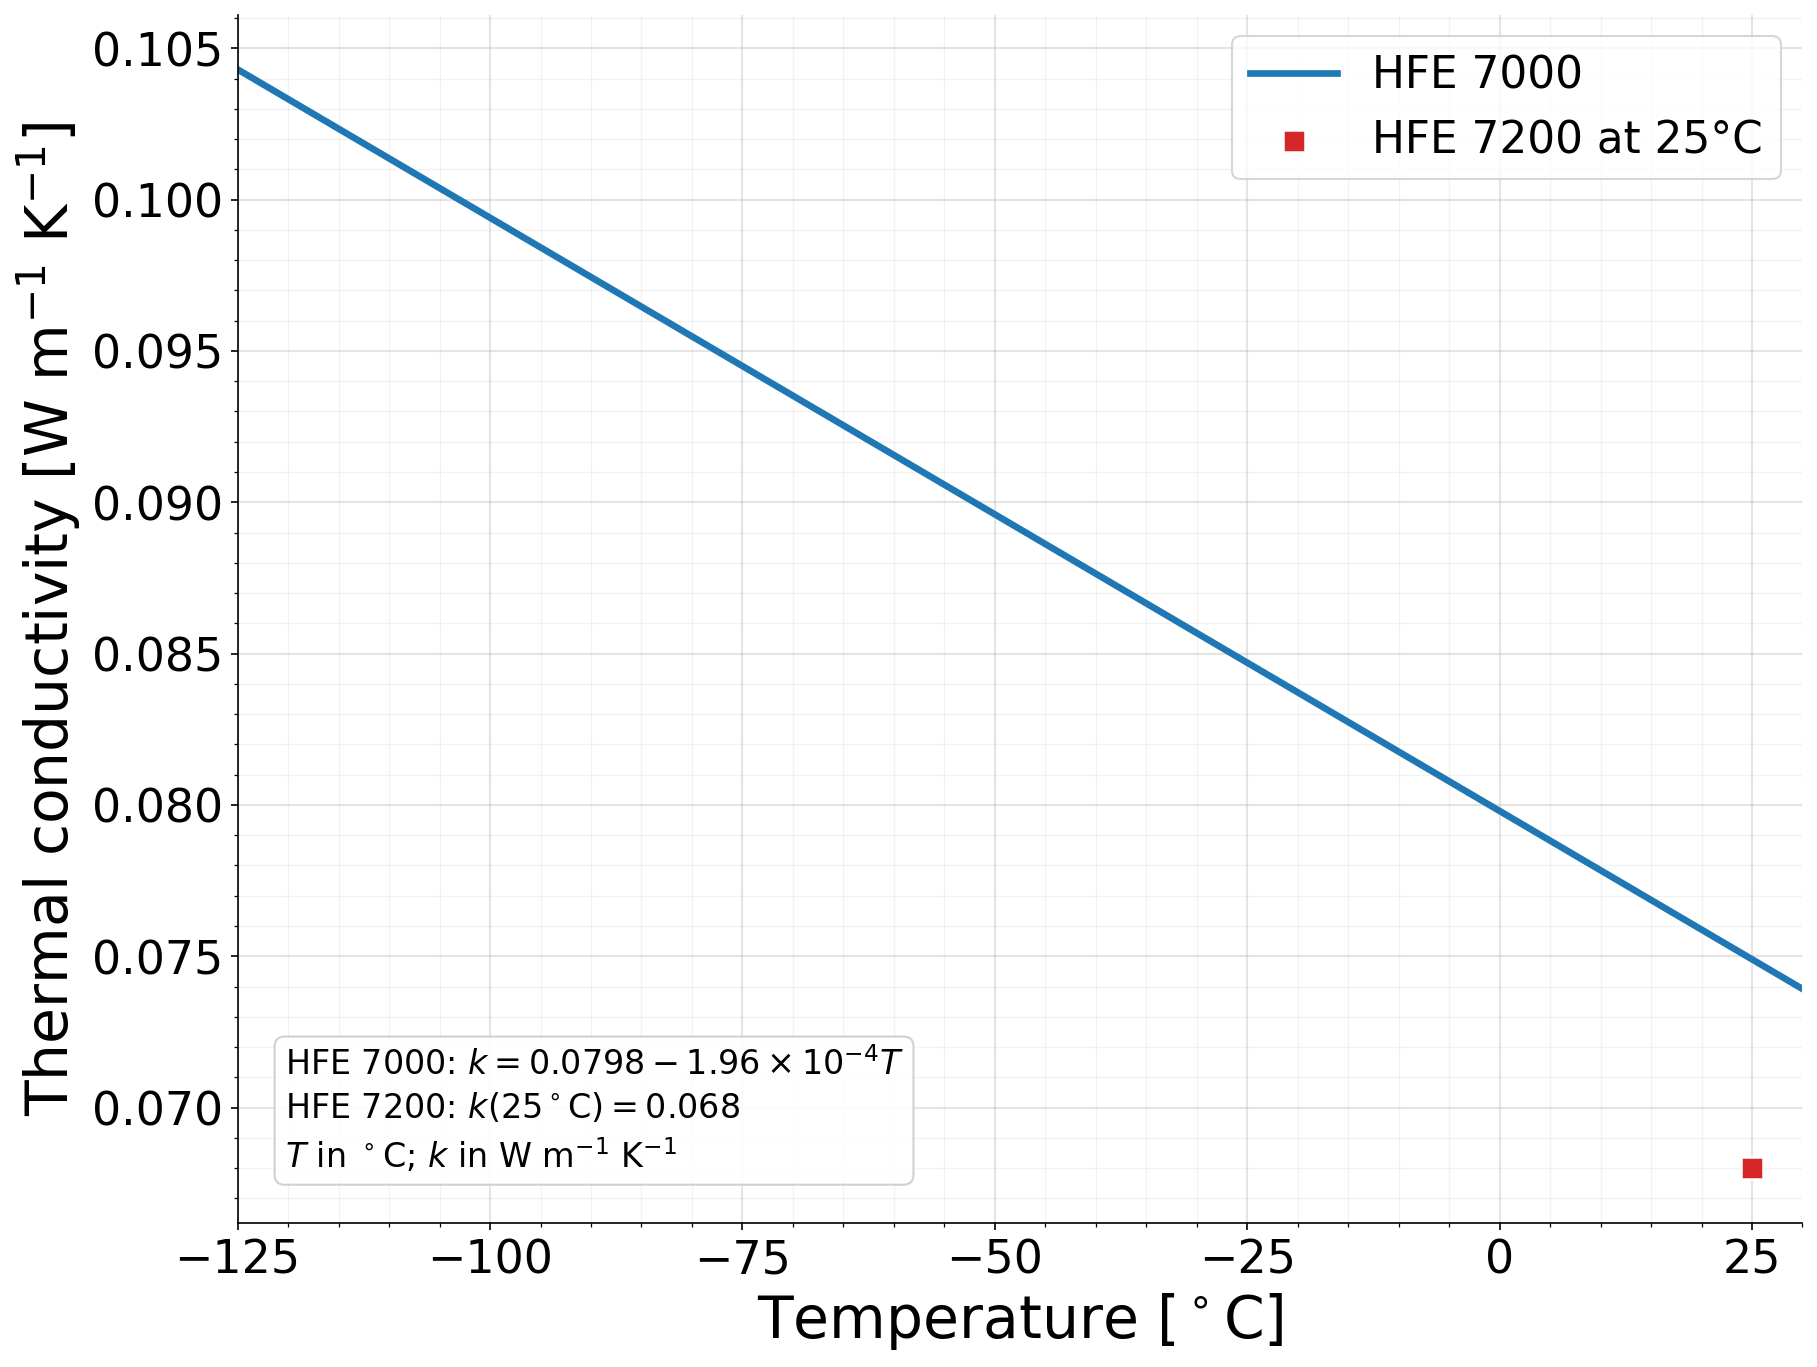

In [6]:
HFE7200_REFERENCE_TEMPERATURE_C = 25.0
HFE7200_THERMAL_CONDUCTIVITY_25C_W_M_K = 0.068
HFE7200_SPECIFIC_HEAT_25C_J_KG_K = 1220.0


def hfe7000_thermal_conductivity_w_m_k(temperature_c):
    """3M Novec 7000 TDS thermal conductivity, W/m/K."""
    return 0.0798 - 0.000196 * np.asarray(temperature_c, dtype=float)


temperature_hfe7000_c = np.linspace(X_AXIS_MIN_C, X_AXIS_MAX_C, 500)

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    temperature_hfe7000_c,
    hfe7000_thermal_conductivity_w_m_k(temperature_hfe7000_c),
    color=COLORS['HFE 7000'],
    label='HFE 7000',
)
ax.scatter(
    [HFE7200_REFERENCE_TEMPERATURE_C],
    [HFE7200_THERMAL_CONDUCTIVITY_25C_W_M_K],
    s=115,
    color=COLORS['HFE 7200'],
    marker='s',
    edgecolor='white',
    linewidth=1.2,
    zorder=3,
    label='HFE 7200 at 25°C',
)

ax.set_xlabel(r'Temperature [$^\circ$C]')
ax.set_ylabel(r'Thermal conductivity [W m$^{-1}$ K$^{-1}$]')
style_temperature_axis(ax)
style_axes(ax)
thermal_conductivity_equation_text = (
    r'HFE 7000: $k = 0.0798 - 1.96\times10^{-4}T$'
    '\n'
    r'HFE 7200: $k(25^\circ\mathrm{C}) = 0.068$'
    '\n'
    r'$T$ in $^\circ$C; $k$ in W m$^{-1}$ K$^{-1}$'
)
add_equation_box(ax, thermal_conductivity_equation_text, loc='lower left', fontsize=16)
ax.legend(loc='upper right')

save_figure(fig, 'hfe_7000_thermal_conductivity')
plt.show()


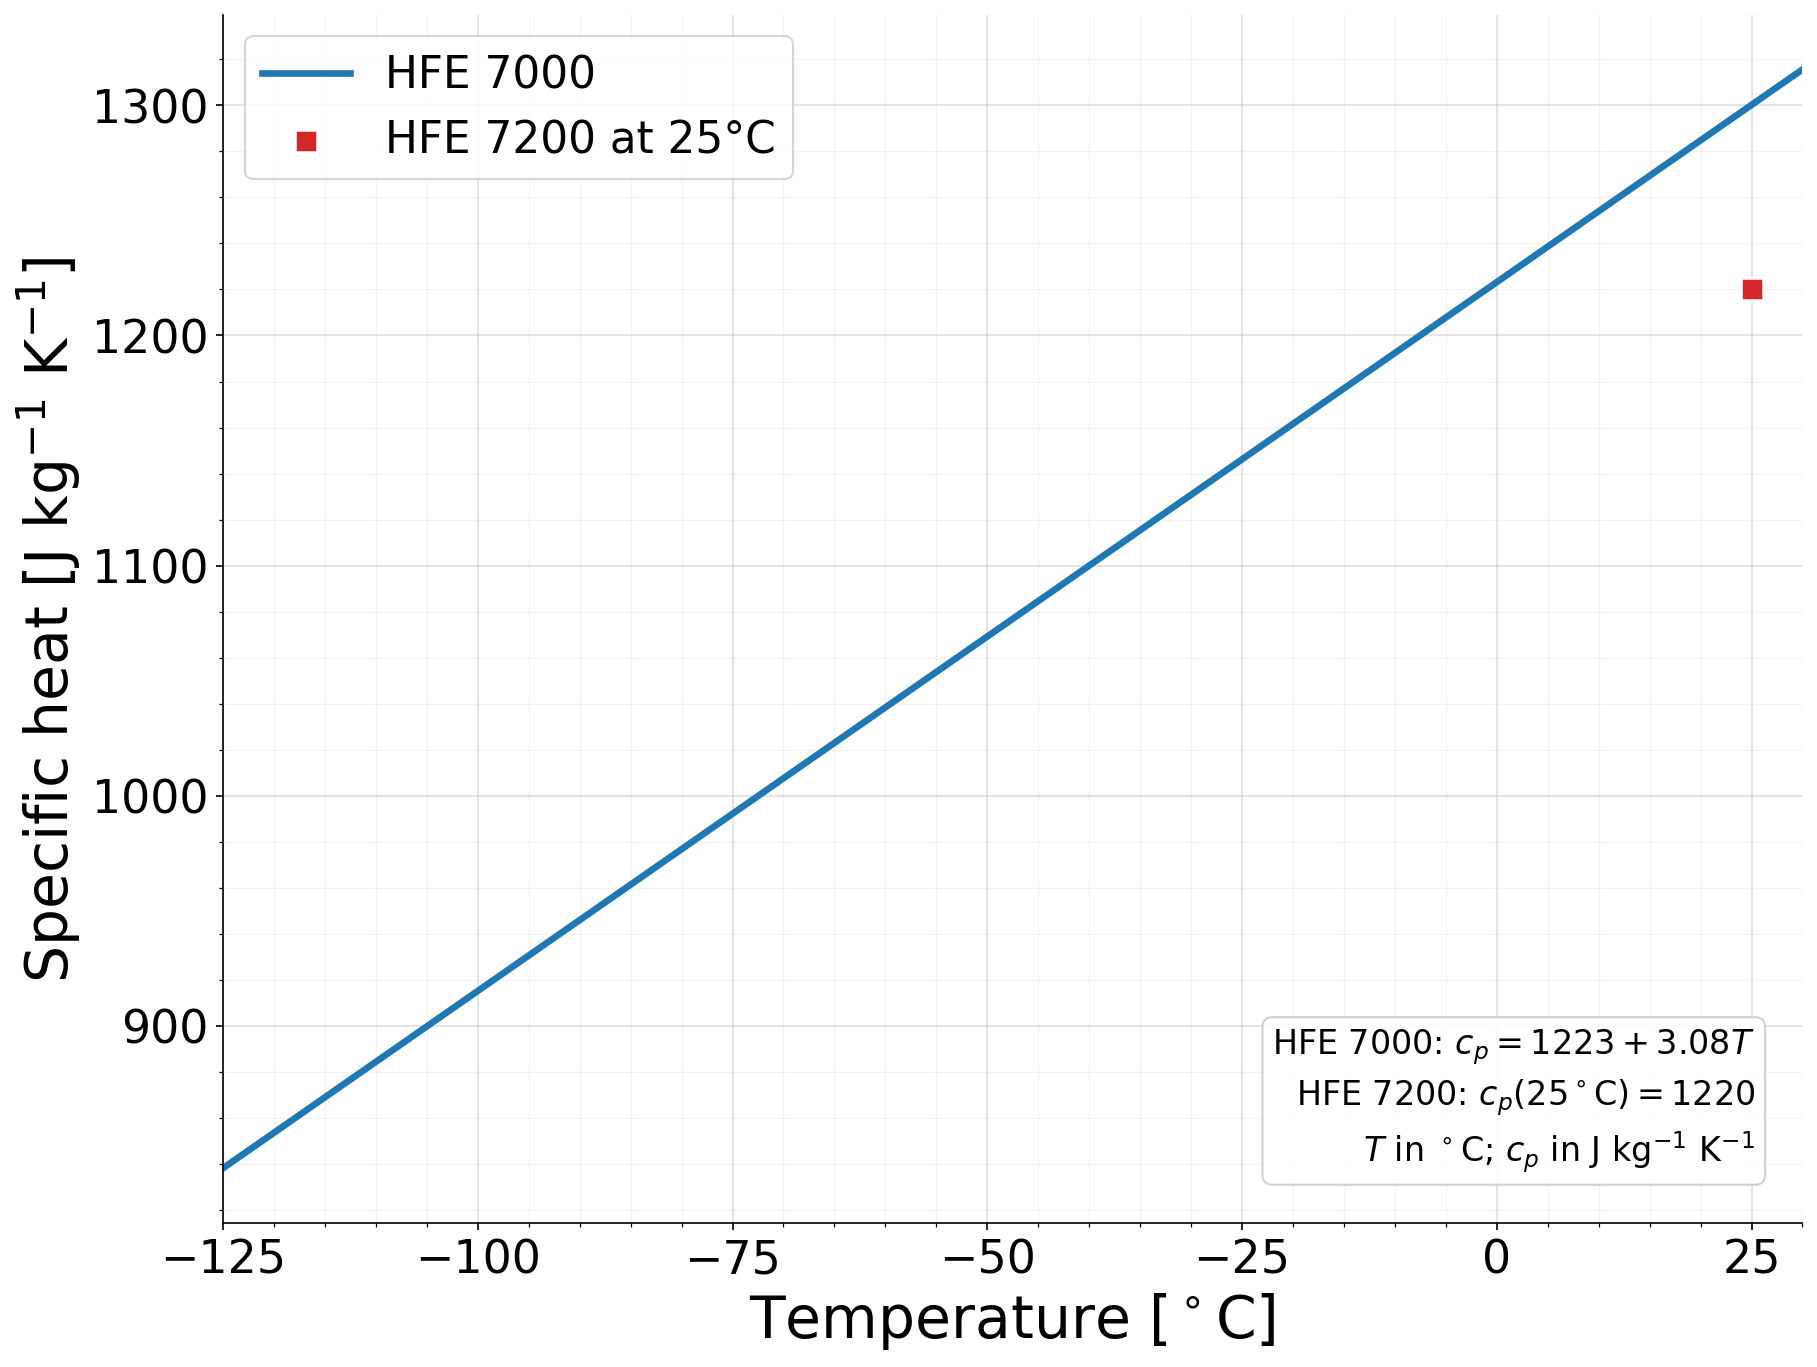

In [7]:
def hfe7000_specific_heat_j_kg_k(temperature_c):
    """3M Novec 7000 TDS specific heat, J/kg/K."""
    return 1223.2 + 3.0803 * np.asarray(temperature_c, dtype=float)


fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

ax.plot(
    temperature_hfe7000_c,
    hfe7000_specific_heat_j_kg_k(temperature_hfe7000_c),
    color=COLORS['HFE 7000'],
    label='HFE 7000',
)
ax.scatter(
    [HFE7200_REFERENCE_TEMPERATURE_C],
    [HFE7200_SPECIFIC_HEAT_25C_J_KG_K],
    s=115,
    color=COLORS['HFE 7200'],
    marker='s',
    edgecolor='white',
    linewidth=1.2,
    zorder=3,
    label='HFE 7200 at 25°C',
)

ax.set_xlabel(r'Temperature [$^\circ$C]')
ax.set_ylabel(r'Specific heat [J kg$^{-1}$ K$^{-1}$]')
style_temperature_axis(ax)
style_axes(ax)
specific_heat_equation_text = (
    r'HFE 7000: $c_p = 1223 + 3.08T$'
    '\n'
    r'HFE 7200: $c_p(25^\circ\mathrm{C}) = 1220$'
    '\n'
    r'$T$ in $^\circ$C; $c_p$ in J kg$^{-1}$ K$^{-1}$'
)
add_equation_box(ax, specific_heat_equation_text, loc='lower right', fontsize=16)
ax.legend(loc='upper left')

save_figure(fig, 'hfe_7000_specific_heat')
plt.show()
